In [1]:
%matplotlib widget
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from ipywidgets import IntSlider, interact

rcParams['font.family'] = 'SimHei'
rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv("../data/raw/may_filtered.csv")
datetimestr = df['date'] + ' ' + df['time']
df['datetime'] = pd.to_datetime(datetimestr, format='%d-%m-%Y %H:%M:%S').astype("datetime64[s]")
df['duration(s)'] = pd.to_timedelta(df.duration).dt.total_seconds()
df.drop(['date', 'time', 'duration'], inplace=True, axis=1)
df['motion'] = np.linalg.norm(df[['accX', 'accY', 'accZ']].values, axis=1)
df = df[["datetime", "duration(s)", "red", "ied", "motion"]]

In [4]:
ied = df.ied
died = ied.diff().abs()
died_freq = died.value_counts()
died_freq_ = died_freq.sort_index(ascending=False)

In [5]:
df_mag = died_freq_.reset_index()
df_mag.columns = ['diff_value', 'count']

vals = df_mag['diff_value'].values
safe_vals = np.where(vals == 0, 1, vals)
df_mag['magnitude'] = np.floor(np.log10(safe_vals)).astype(int)

In [6]:
df_mag

,diff_value,count,magnitude
0,3444827.0,1,6
1,3251278.0,1,6
2,3162199.0,1,6
3,3133518.0,1,6
4,3064820.0,1,6
...,...,...,...
56116,4.0,5527,0
56117,3.0,10865,0
56118,2.0,5560,0
56119,1.0,5463,0


<Axes: >

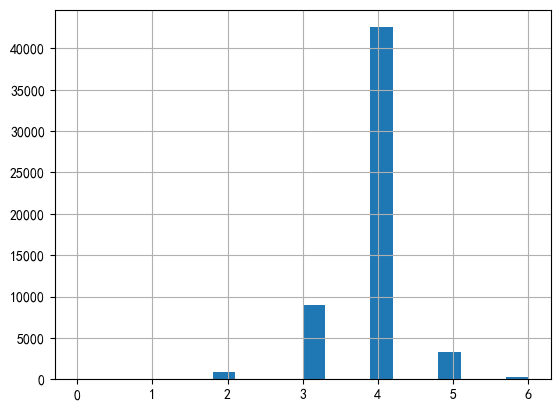

In [7]:
df_mag["magnitude"].hist(bins=20)

In [13]:
df_mag['magnitude'].value_counts().sort_index(ascending=False)

magnitude
6      277
5     3313
4    42531
3     9000
2      900
1       90
0       10
Name: count, dtype: int64